In [1]:
# Install & import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # Check missing values
print(df['target'].value_counts())  # Class balance

(569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

/tmp/ipykernel_3047/4092202398.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


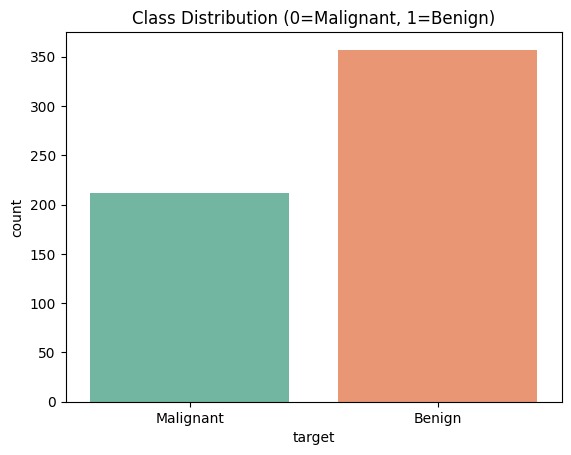

In [3]:
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Class Distribution (0=Malignant, 1=Benign)')
plt.xticks([0,1], ['Malignant', 'Benign'])
plt.show()

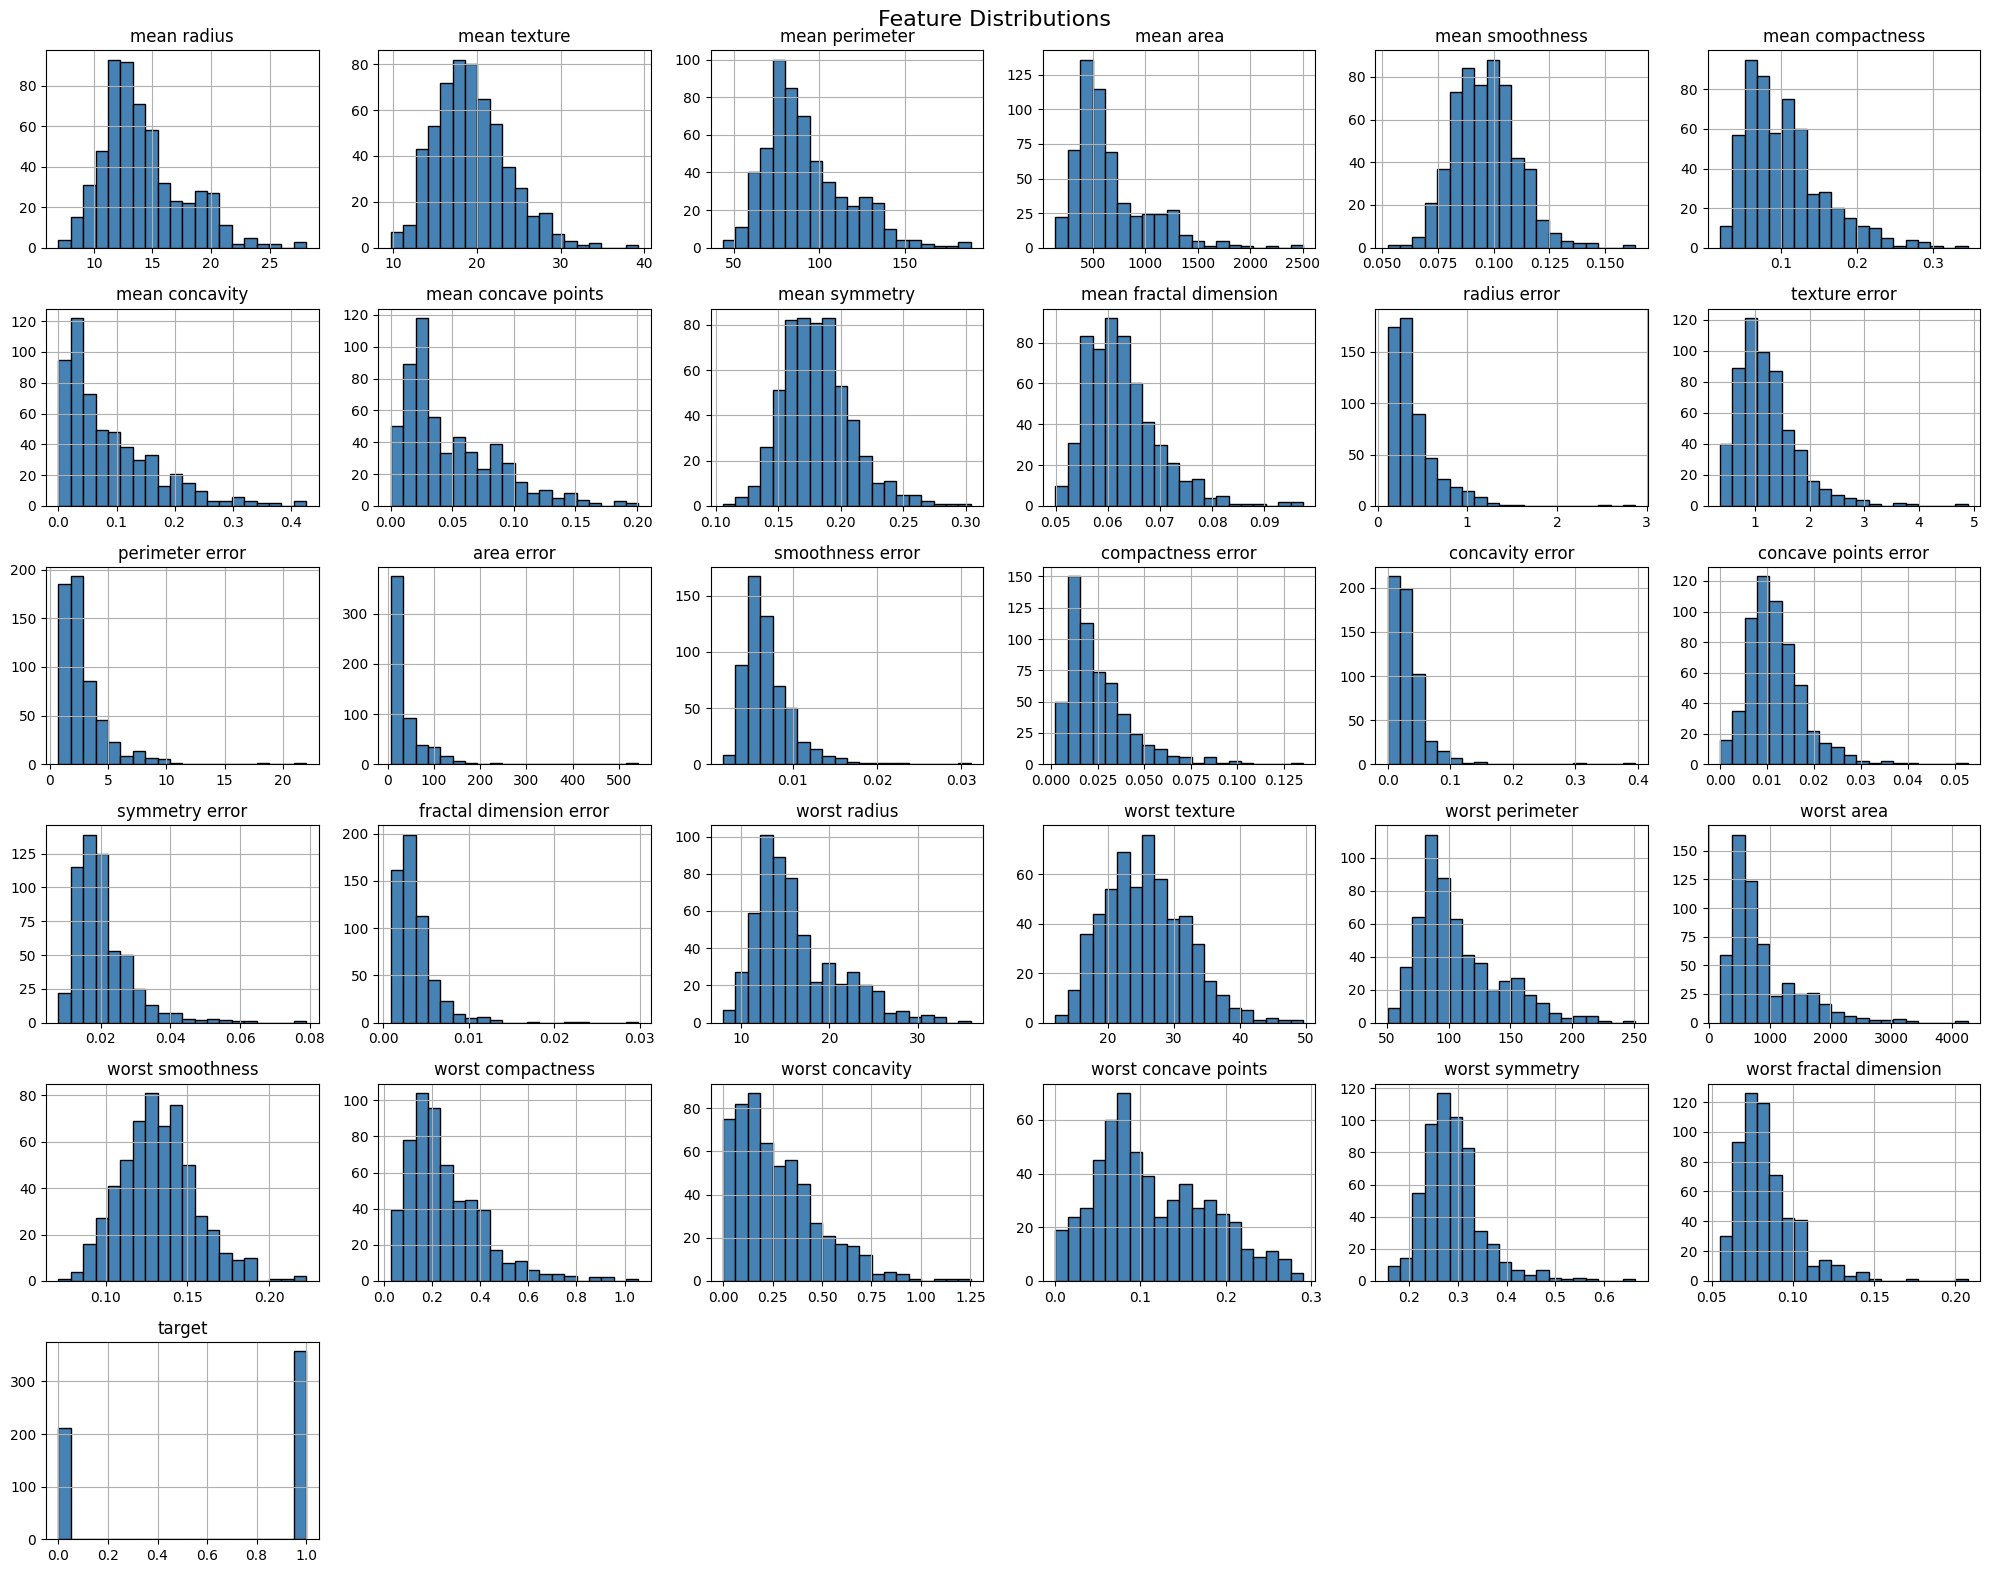

In [4]:
df.hist(figsize=(20, 16), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

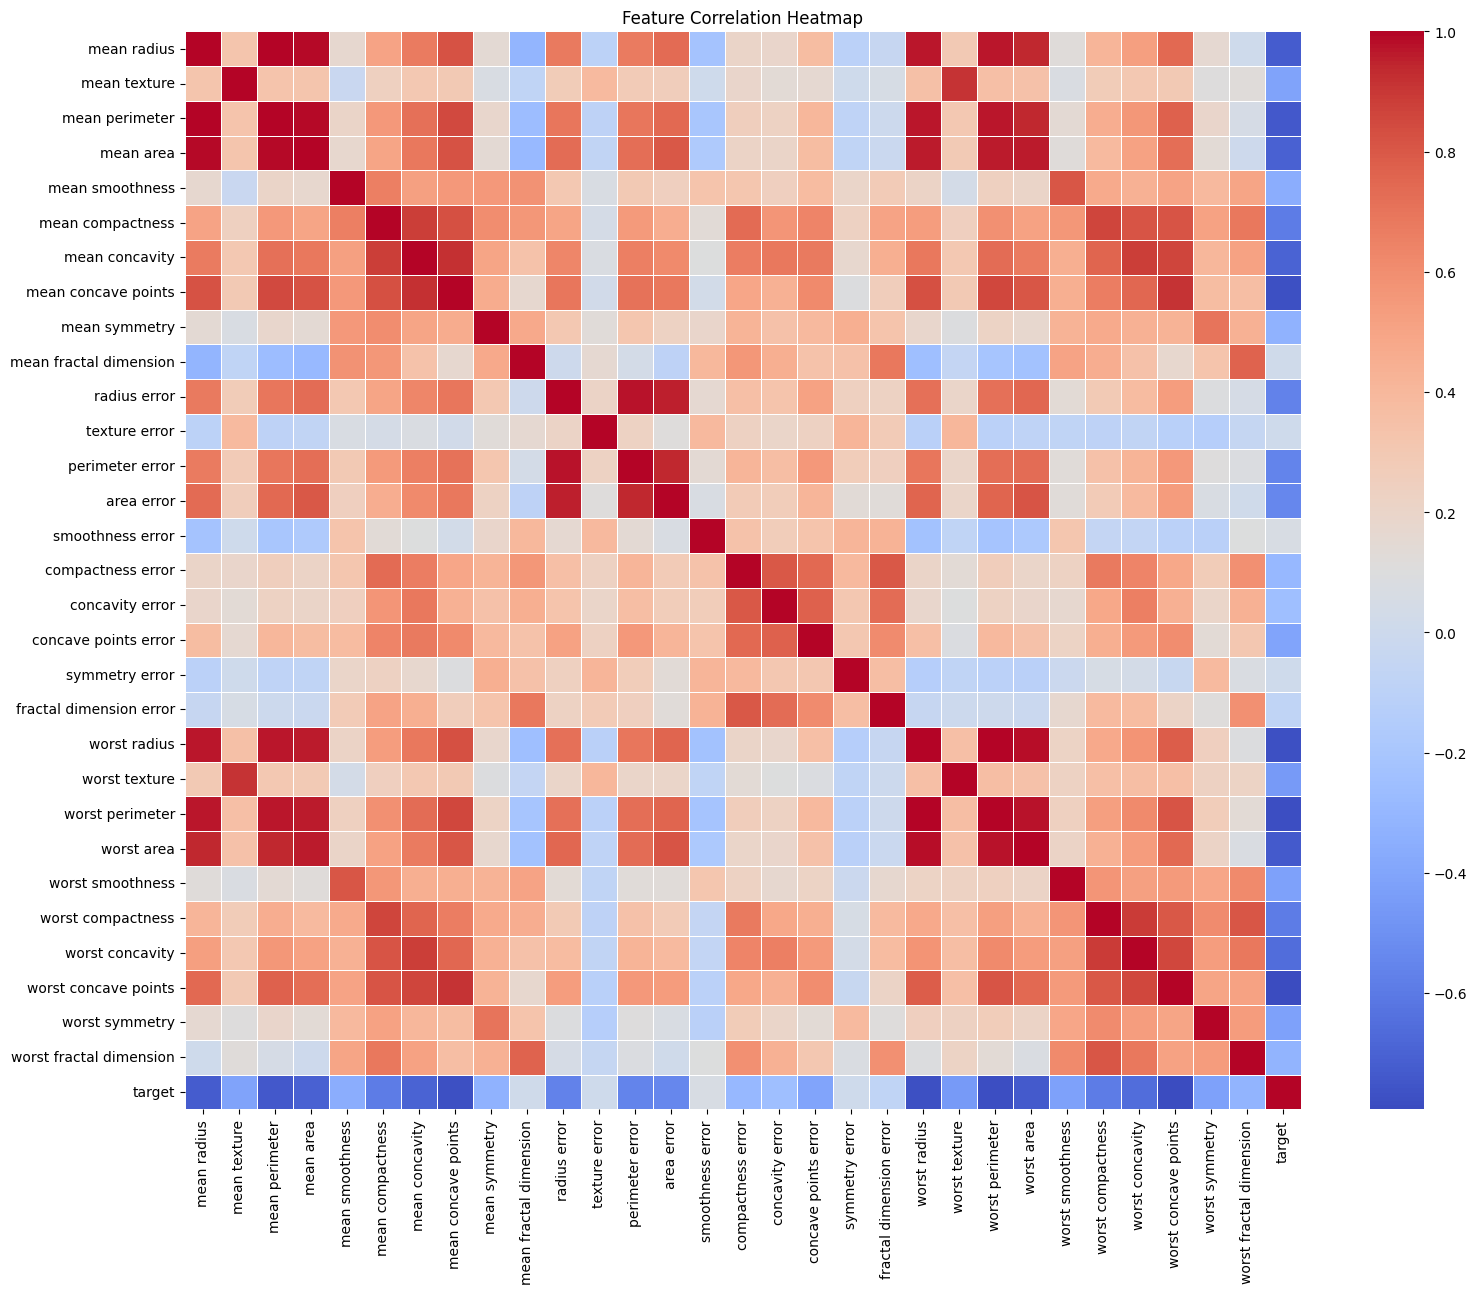

In [5]:
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

/tmp/ipykernel_3047/1024766795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feat, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3047/1024766795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feat, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3047/1024766795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feat, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_3047/1024766795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

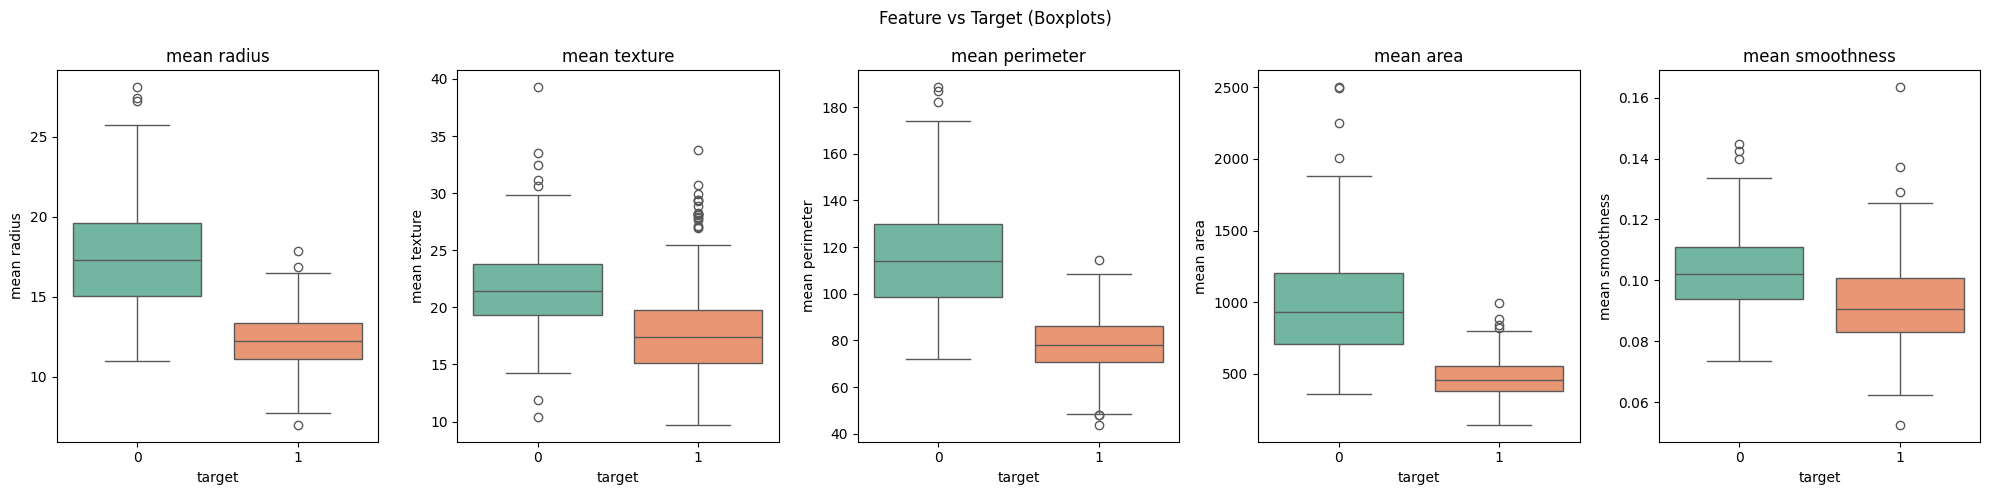

In [6]:
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, feat in enumerate(top_features):
    sns.boxplot(x='target', y=feat, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(feat)
plt.suptitle('Feature vs Target (Boxplots)')
plt.tight_layout()
plt.show()

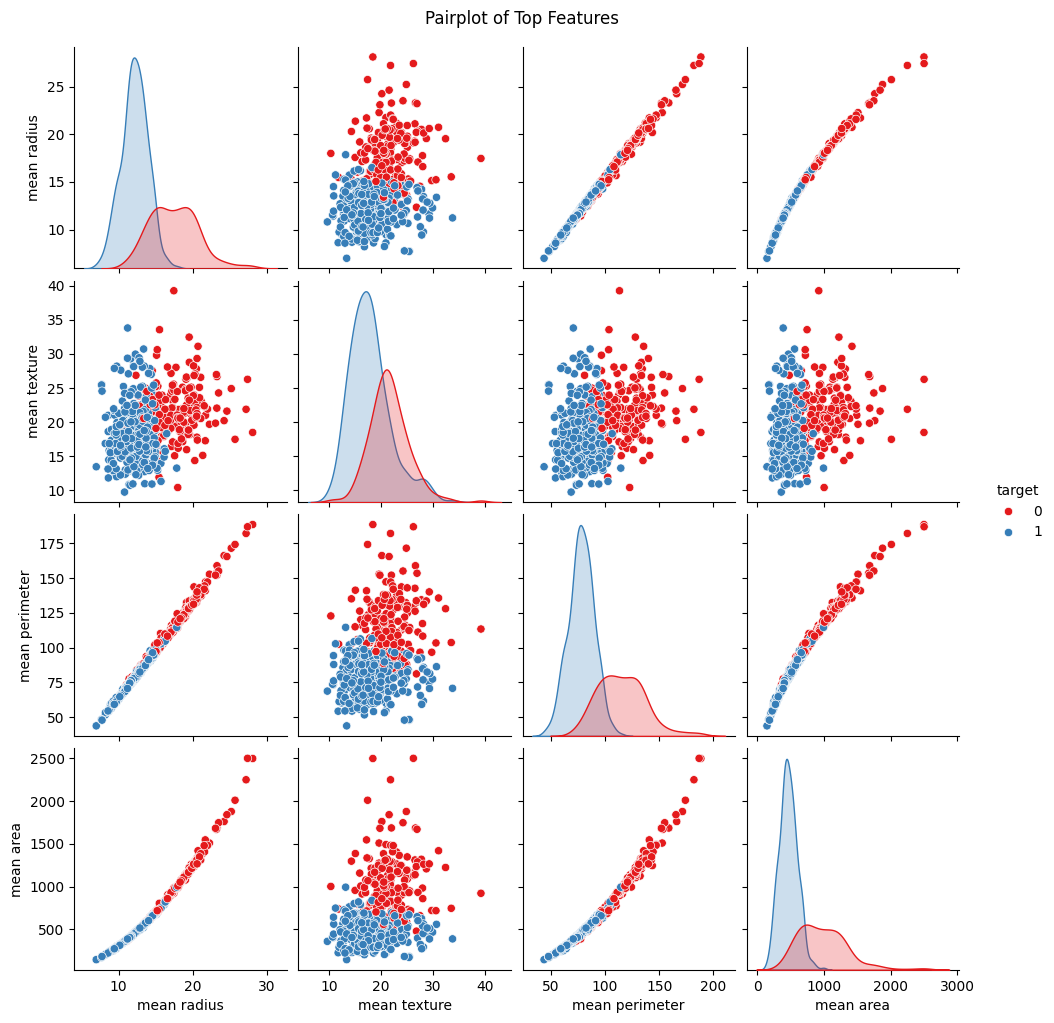

In [7]:
sns.pairplot(df[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']],
             hue='target', palette='Set1', diag_kind='kde')
plt.suptitle('Pairplot of Top Features', y=1.02)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (398, 30), Val: (85, 30), Test: (86, 30)


In [9]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svm_base = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_base.fit(X_train, y_train)

y_val_pred = svm_base.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.9764705882352941
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        32
           1       1.00      0.96      0.98        53

    accuracy                           0.98        85
   macro avg       0.97      0.98      0.98        85
weighted avg       0.98      0.98      0.98        85



In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'degree': [2, 3, 4]  # only used for poly kernel
}

grid = GridSearchCV(SVC(probability=True, random_state=42),
                    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
best_svm = grid.best_estimator_

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Params: {'C': 10, 'degree': 2, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV Accuracy: 0.9799050632911392


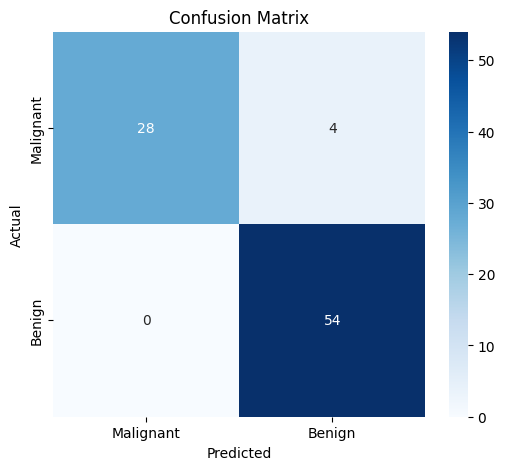

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_test_pred = best_svm.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'])
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

y_proba = best_svm.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_test_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_proba):.4f}")

Accuracy : 0.9535
Precision: 0.9310
Recall   : 1.0000
F1-Score : 0.9643
AUC      : 0.9931


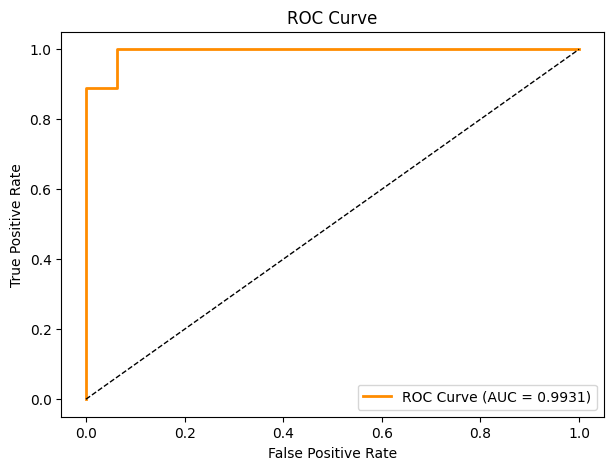

In [13]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.show()

In [14]:
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred,
    'Prob_Malignant': best_svm.predict_proba(X_test)[:, 0].round(3),
    'Prob_Benign':    best_svm.predict_proba(X_test)[:, 1].round(3)
})
print(results_df.head(15).to_string(index=False))

 Actual  Predicted  Prob_Malignant  Prob_Benign
      1          1           0.007        0.993
      0          0           1.000        0.000
      0          0           1.000        0.000
      0          0           1.000        0.000
      0          1           0.204        0.796
      1          1           0.140        0.860
      0          1           0.209        0.791
      1          1           0.003        0.997
      1          1           0.447        0.553
      0          0           0.637        0.363
      1          1           0.296        0.704
      1          1           0.132        0.868
      1          1           0.176        0.824
      0          0           0.896        0.104
      1          1           0.000        1.000


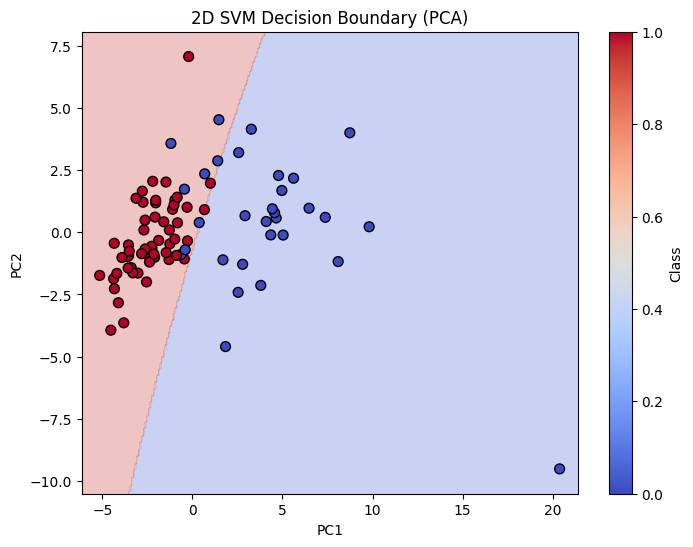

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)

# Train a new SVM on 2D data for the boundary plot
svm_2d = SVC(kernel=grid.best_params_['kernel'], C=grid.best_params_['C'],
             gamma=grid.best_params_.get('gamma','scale'), probability=True)
svm_2d.fit(pca.fit_transform(X_train), y_train)

# Plot
xx, yy = np.meshgrid(np.linspace(X_test_2d[:,0].min()-1, X_test_2d[:,0].max()+1, 300),
                     np.linspace(X_test_2d[:,1].min()-1, X_test_2d[:,1].max()+1, 300))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_test_2d[:,0], X_test_2d[:,1], c=y_test, cmap='coolwarm', edgecolors='k', s=50)
plt.title('2D SVM Decision Boundary (PCA)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(scatter, label='Class')
plt.show()

In [17]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Save dataset
df.to_csv('/content/drive/MyDrive/data.csv', index=False)
print("Saved!")

Mounted at /content/drive
Saved!
